In [2]:
import os
os.environ.setdefault("BCD_DATA_FOLDER", "/data/gaetane")  # adapte si besoin

import torch
import matplotlib.pyplot as plt
import numpy as np

from dataloader import HiUCD_Dataset 
from encoder import DinoV2Encoder
from encoder import ChangeDetectionModel
from encoder import FeatureTransformer

In [3]:
ds_train = HiUCD_Dataset(cropsize=256, type="train", everything=True)

image1, image2, changemap, changemap2, landcover1, landcover2 = ds_train[9]

print("image1:", image1.shape, image1.dtype, image1.min().item(), image1.max().item())
print("image2:", image2.shape, image2.dtype, image2.min().item(), image2.max().item())
print("changemap:", changemap.shape, changemap.dtype, torch.unique(changemap))
print("landcover1:", landcover1.shape, landcover1.dtype, torch.unique(landcover1))
print("landcover2:", landcover2.shape, landcover2.dtype, torch.unique(landcover2))

image1: torch.Size([3, 256, 256]) torch.float32 0.05098039284348488 1.0
image2: torch.Size([3, 256, 256]) torch.float32 0.05098039284348488 0.9137254953384399
changemap: torch.Size([256, 256]) torch.int32 tensor([0], dtype=torch.int32)
landcover1: torch.Size([256, 256]) torch.int64 tensor([3, 5, 8])
landcover2: torch.Size([256, 256]) torch.int64 tensor([3, 5, 8])


In [4]:
diff_mask = (landcover1 != landcover2).int()
changemap_np = changemap.squeeze().numpy()
diff_np = diff_mask.squeeze().numpy() if diff_mask.dim() > 2 else diff_mask.numpy()

agreement = (changemap_np == diff_np).mean()
print(f"Accord changemap vs (landcover1 != landcover2): {agreement:.3f}")
print("Proportion de pixels 'changé' dans changemap:", changemap_np.mean())
print("Proportion de pixels avec landcover1 != landcover2:", diff_np.mean())

Accord changemap vs (landcover1 != landcover2): 1.000
Proportion de pixels 'changé' dans changemap: 0.0
Proportion de pixels avec landcover1 != landcover2: 0.0


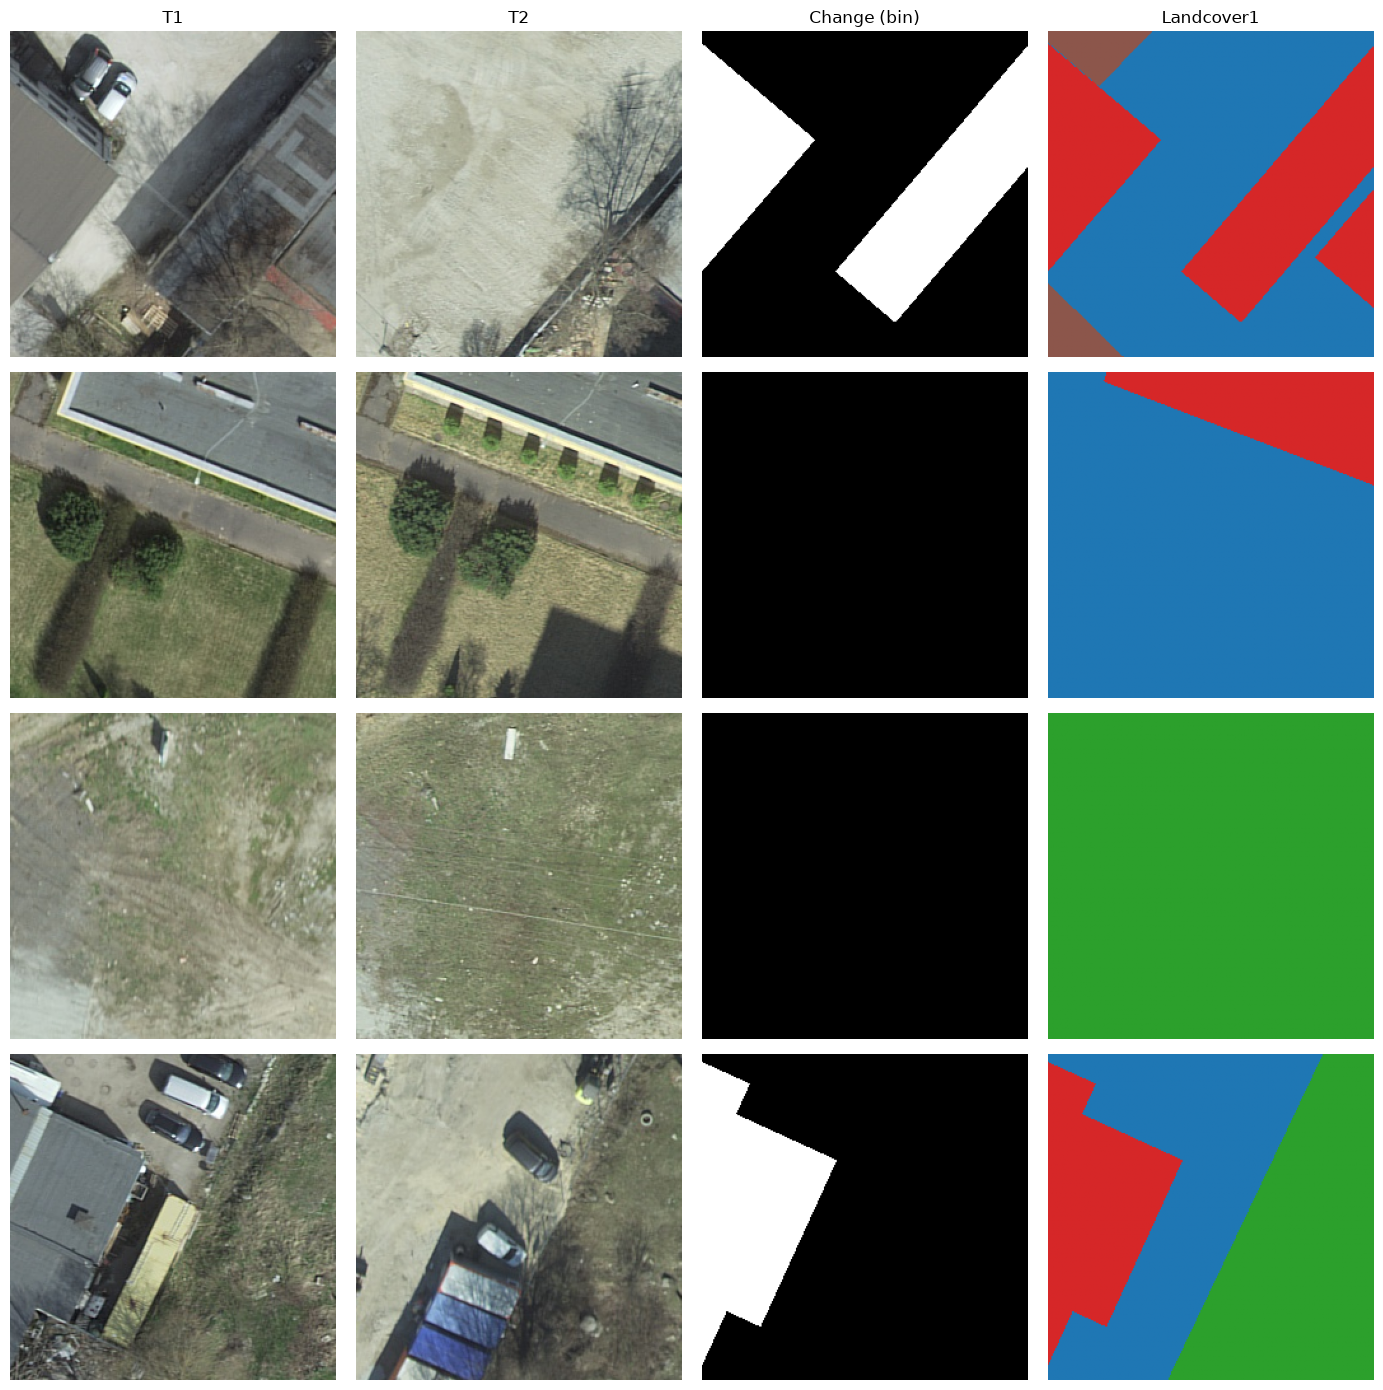

In [5]:
from torch.utils.data import DataLoader

loader = DataLoader(ds_train, batch_size=4, shuffle=True)
image1, image2, changemap, _, landcover1, landcover2 = next(iter(loader))

fig, axs = plt.subplots(4, 4, figsize=(14, 14))
titles = ["T1", "T2", "Change (bin)", "Landcover1"]
for i in range(4):
    axs[i, 0].imshow(image1[i].permute(1, 2, 0))
    axs[i, 1].imshow(image2[i].permute(1, 2, 0))
    axs[i, 2].imshow(changemap[i], cmap="gray", vmin=0, vmax=1)
    axs[i, 3].imshow(landcover1[i], cmap="tab10", vmin=0, vmax=9)
    for j in range(4):
        axs[i, j].axis("off")
        if i == 0:
            axs[i, j].set_title(titles[j])
plt.tight_layout()
plt.show()


## Vérification encodeur 


In [6]:
encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224)

im1, im2, changemap, _, landcover1, landcover2 = ds_train[0]
im1_batch = im1.unsqueeze(0)

with torch.no_grad():
    x = encoder(im1_batch)

print("x shape:", x.shape)
print("out_channels attendu:", encoder.out_channels)

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main
/home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


x shape: torch.Size([1, 384, 16, 16])
out_channels attendu: 384


In [7]:
encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224)
transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6)
model = ChangeDetectionModel(encoder, transformer)

im1, im2, changemap, _, landcover1, landcover2 = ds_train[0]
im1_batch, im2_batch = im1.unsqueeze(0), im2.unsqueeze(0)

x_hat, y = model(im1_batch, im2_batch)
print("x_hat:", x_hat.shape)
print("y:", y.shape)

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main


x_hat: torch.Size([1, 384, 16, 16])
y: torch.Size([1, 384, 16, 16])


In [8]:
print(ds_train.cropsize)

256


check forward

In [9]:
encoder = DinoV2Encoder(model_name="dinov2_vits14", freeze=True, resize_to=224)
transformer = FeatureTransformer(embed_dim=encoder.out_channels, n_heads=6)
model = ChangeDetectionModel(encoder, transformer)

im1, im2, changemap, _, landcover1, landcover2 = ds_train[0]
im1_batch, im2_batch = im1.unsqueeze(0), im2.unsqueeze(0)

x_hat, y = model(im1_batch, im2_batch)
print("x_hat:", x_hat.shape, x_hat.requires_grad)
print("y:", y.shape, y.requires_grad)

Using cache found in /home/gaetane/.cache/torch/hub/facebookresearch_dinov2_main


x_hat: torch.Size([1, 384, 16, 16]) True
y: torch.Size([1, 384, 16, 16]) False


backward une fois 

In [10]:
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.transformer.parameters(), lr=1e-4)

params_before = [p.clone().detach() for p in model.transformer.parameters()]

optimizer.zero_grad()
x_hat, y = model(im1_batch, im2_batch)
loss = loss_fn(x_hat, y)
loss.backward()
optimizer.step()

params_after = [p.clone().detach() for p in model.transformer.parameters()]

changed = [not torch.equal(a, b) for a, b in zip(params_before, params_after)]
print("Loss initiale:", loss.item())
print("Tous les paramètres ont changé:", all(changed))
print("Nombre de paramètres inchangés:", changed.count(False))

Loss initiale: 5.676117420196533
Tous les paramètres ont changé: True
Nombre de paramètres inchangés: 0


overfit sur un batch

In [13]:
from torch.utils.data import DataLoader

loader = DataLoader(ds_train, batch_size=4, shuffle=True)
im1_fixed, im2_fixed, cm_fixed, _, lc1_fixed, lc2_fixed = next(iter(loader))

model = ChangeDetectionModel(encoder, transformer)
optimizer = torch.optim.Adam(model.transformer.parameters(), lr=1e-2) #learning rate
loss_fn = torch.nn.MSELoss()

losses = []
for step in range(300):
    optimizer.zero_grad()
    x_hat, y = model(im1_fixed, im2_fixed)
    loss = loss_fn(x_hat, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if step % 10 == 0:
        print(f"step {step}: loss = {loss.item():.6f}")

step 0: loss = 4.637192
step 10: loss = 3.537204
step 20: loss = 3.464811
step 30: loss = 3.445446
step 40: loss = 3.432523
step 50: loss = 3.426905
step 60: loss = 3.422112
step 70: loss = 3.418284
step 80: loss = 3.416358
step 90: loss = 3.410366
step 100: loss = 3.406507
step 110: loss = 3.401239
step 120: loss = 3.398196
step 130: loss = 3.390310
step 140: loss = 3.386557
step 150: loss = 3.383342
step 160: loss = 3.380549
step 170: loss = 3.374214
step 180: loss = 3.372461
step 190: loss = 3.368500
step 200: loss = 3.364261
step 210: loss = 3.364450
step 220: loss = 3.360595
step 230: loss = 3.355203
step 240: loss = 3.352531
step 250: loss = 3.351993
step 260: loss = 3.347974
step 270: loss = 3.344959
step 280: loss = 3.342961
step 290: loss = 3.342216


In [14]:
print(transformer.pos_embed.shape)
id_before = id(transformer.pos_embed)

for step in range(5):
    x_hat, y = model(im1_fixed, im2_fixed)
    loss = loss_fn(x_hat, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

id_after = id(transformer.pos_embed)
print("Même objet pos_embed:", id_before == id_after)

torch.Size([1, 256, 384])
Même objet pos_embed: True
